/tmp/ipykernel_3132/1815605256.py:17: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html_data, "html.parser")


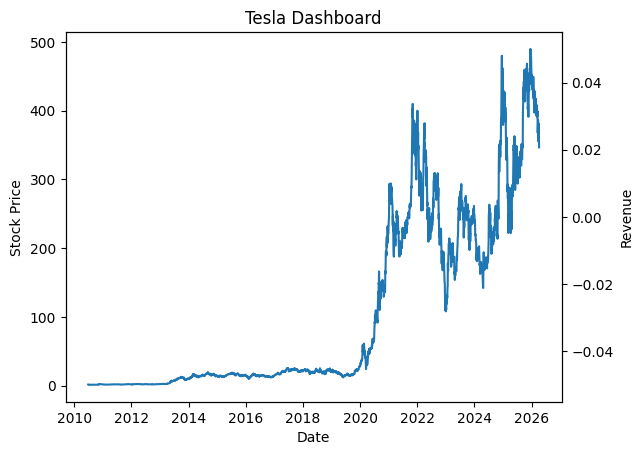

In [8]:
# Q5_Tesla_Dashboard.py

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

# Stock Data
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

# Revenue Data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0221EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in soup.find_all("table"):
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.find_all("tr")[1:]:
            col = row.find_all("td")
            if len(col) > 1:
                tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({
                    "Date": [col[0].text],
                    "Revenue": [col[1].text]
                })])

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',', '').str.replace('$', '')
tesla_revenue.dropna(inplace=True)

# Plot
fig, ax1 = plt.subplots()

ax1.plot(tesla_data["Date"], tesla_data["Close"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Stock Price")

ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(tesla_revenue["Date"]), tesla_revenue["Revenue"].astype("float"))
ax2.set_ylabel("Revenue")

plt.title("Tesla Dashboard")
plt.show()